Name-Riya choudhary

Subject-Computer vision lab

CUID-CU24250251

**Experiment No. 10**

Character, Digit, or Face Classification using Convolutional Neural Networks (CNNs)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.20.0


In [2]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("MNIST dataset loaded successfully!")
print("Full training data shape:", x_train_full.shape)
print("Training labels shape:", y_train_full.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST dataset loaded successfully!
Full training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


In [3]:
# Normalize pixel values from 0-255 to 0-1
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
# Add channel dimension
# (60000, 28, 28) -> (60000, 28, 28, 1)
x_train_full = np.expand_dims(x_train_full, -1)
x_test = np.expand_dims(x_test, -1)
# Create validation set from the first 5000 training images
val_size = 5000
x_val = x_train_full[:val_size]
y_val = y_train_full[:val_size]
x_train = x_train_full[val_size:]
y_train = y_train_full[val_size:]
print("Preprocessing completed successfully!")
print("Training data shape:", x_train.shape)
print("Validation data shape:", x_val.shape)
print("Test data shape:", x_test.shape)

Preprocessing completed successfully!
Training data shape: (55000, 28, 28, 1)
Validation data shape: (5000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


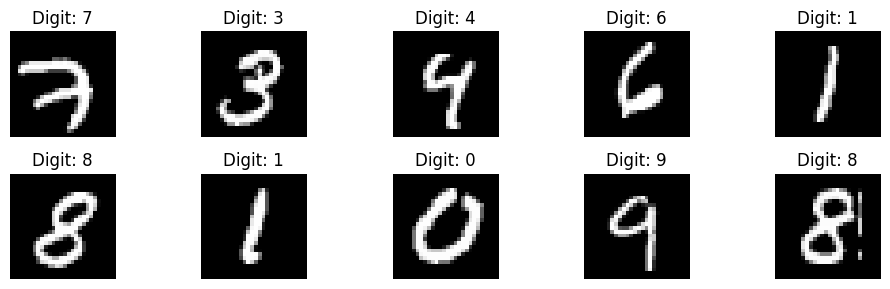

In [6]:
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # First convolution layer
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution layer
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into a single vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Reduce overfitting
    layers.Dropout(0.3),

    # Output layer: 10 digits (0-9)
    layers.Dense(10, activation="softmax")
])
print("CNN model created successfully!")
model.summary()

CNN model created successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
BATCH_SIZE = 128
EPOCHS = 5
print("CNN model compiled successfully!")
print("Starting training...\n")
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    verbose=2
)
print("\nCNN training completed successfully!")

CNN model compiled successfully!
Starting training...

Epoch 1/5
430/430 - 49s - 115ms/step - accuracy: 0.9276 - loss: 0.2410 - val_accuracy: 0.9804 - val_loss: 0.0619
Epoch 2/5
430/430 - 43s - 100ms/step - accuracy: 0.9783 - loss: 0.0714 - val_accuracy: 0.9856 - val_loss: 0.0473
Epoch 3/5
430/430 - 83s - 192ms/step - accuracy: 0.9836 - loss: 0.0528 - val_accuracy: 0.9874 - val_loss: 0.0416
Epoch 4/5
430/430 - 42s - 99ms/step - accuracy: 0.9876 - loss: 0.0418 - val_accuracy: 0.9898 - val_loss: 0.0346
Epoch 5/5
430/430 - 81s - 189ms/step - accuracy: 0.9890 - loss: 0.0343 - val_accuracy: 0.9916 - val_loss: 0.0341

CNN training completed successfully!


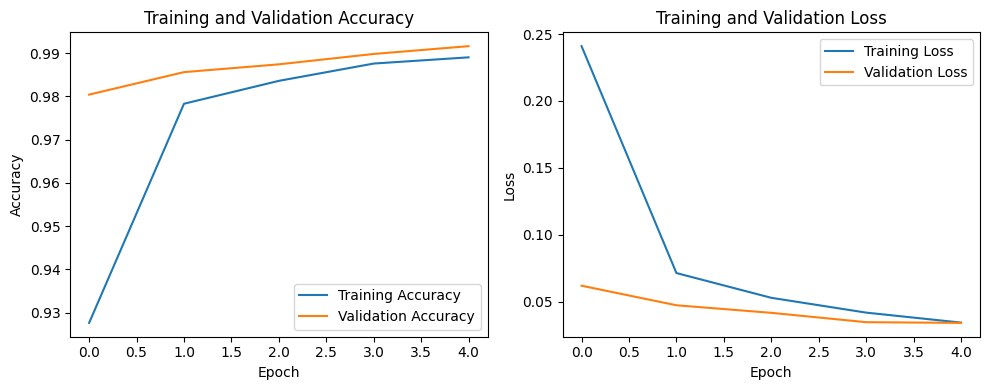

In [11]:
plt.figure(figsize=(10, 4))
# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)
print("Test Evaluation")
print("----------------")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
# Generate predictions
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
print("\nPredictions generated successfully!")

Test Evaluation
----------------
Test Accuracy: 0.9919
Test Loss: 0.0242

Predictions generated successfully!


Classification Report
----------------------
              precision    recall  f1-score   support

           0     0.9889    0.9959    0.9924       980
           1     0.9930    1.0000    0.9965      1135
           2     0.9904    0.9952    0.9928      1032
           3     0.9950    0.9901    0.9926      1010
           4     0.9959    0.9919    0.9939       982
           5     0.9921    0.9910    0.9916       892
           6     0.9968    0.9885    0.9927       958
           7     0.9818    0.9961    0.9889      1028
           8     0.9938    0.9877    0.9907       974
           9     0.9920    0.9812    0.9865      1009

    accuracy                         0.9919     10000
   macro avg     0.9920    0.9918    0.9918     10000
weighted avg     0.9919    0.9919    0.9919     10000


Confusion Matrix
----------------
[[ 976    0    1    0    0    0    1    1    1    0]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   0    1 1027    0    0    0    0    4    0    0]
 [

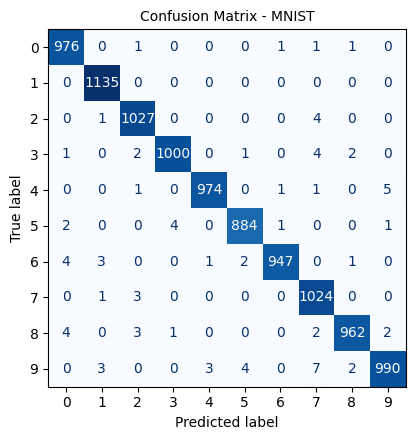

In [16]:
print("Classification Report")
print("----------------------")

print(classification_report(
    y_test,
    y_pred,
    digits=4
))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print("----------------")
print(cm)
# Display confusion matrix in smaller size
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(range(10))
)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Confusion Matrix - MNIST",
    fontsize=10
)

plt.tight_layout()
plt.show()

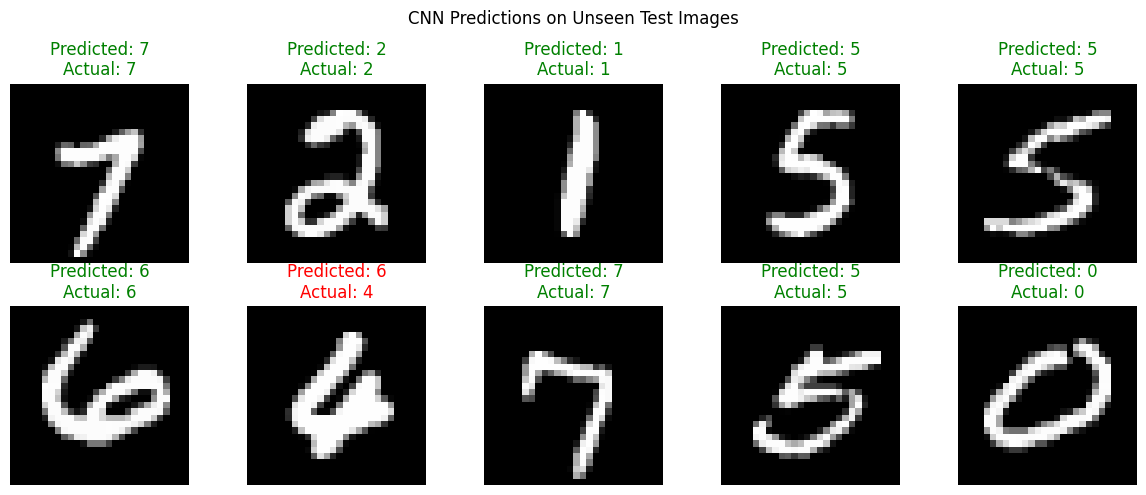

Unseen image prediction completed successfully!


In [14]:
import random
sample_indices = random.sample(range(len(x_test)), 10)
plt.figure(figsize=(12, 5))
for i, idx in enumerate(sample_indices):
    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[idx].squeeze(), cmap="gray")

    predicted = y_pred[idx]
    actual = y_test[idx]

    if predicted == actual:
        title_color = "green"
    else:
        title_color = "red"

    plt.title(
        f"Predicted: {predicted}\nActual: {actual}",
        color=title_color
    )
    plt.axis("off")
plt.suptitle("CNN Predictions on Unseen Test Images")
plt.tight_layout()
plt.show()
print("Unseen image prediction completed successfully!")